# PRAGMA Phase 9 - Run a PRAGMA-S pilot corpus

Implementation plan section 13.2/14.2, `plans/progress.md` Phase 9. Everything through Phase 8 proved the *pipeline* is correct on tiny (12-40 entity) smoke-test data. This notebook is the first run sized to say something about *representation learning*: a few hundred entities' worth of history, an AdamW-only pilot, a hybrid Muon+AdamW comparison against it, and - the actual exit gate - checking whether a **frozen** checkpoint's `[USR]` embeddings carry any signal for a downstream label the model never saw as input.

**`CFG.DEBUG`** follows the same convention as `007_debug_training.ipynb`/`009_distributed_pretraining.ipynb`: `True` (the default this notebook is committed with) runs in well under a minute for CI/smoke-test purposes; `False` is the actual pilot scale this phase is about (measured directly on this dev machine: ~300 entities, 5 epochs, two optimizers -> ~3 minutes total on CPU). The **Pilot run results** section near the end reports numbers from an actual `DEBUG=False` run, captured once and pasted in as markdown, since the notebook itself is committed in its fast `DEBUG=True` form.

**The downstream label.** `pragma.data.synthetic` now adds `_downstream_is_high_value` to the profile table: `True` if an entity's total transaction volume is above the corpus median, computed from that entity's *own* events. It is underscore-prefixed like `_edge_case_profile`, so `SchemaRegistry` validation ignores it and it never reaches the model as an input (`PointInTimeRecordBuilder` only reads `registry.profile_fields`) - it exists purely so this notebook has *something* to probe for that is actually derived from the event history, unlike `is_active` (assigned independently of events, so no embedding could ever predict it).

In [1]:
import shutil
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from mlflow.tracking import MlflowClient

from pragma.config import MaskingConfig, ProcessorConfig, TokenBudgetConfig, TrainingConfig
from pragma.data.dataset import TokenizedRecordDataset
from pragma.data.records import PointInTimeRecordBuilder, SplitConfig
from pragma.data.storage import ParquetShardStore
from pragma.data.synthetic import SyntheticDataConfig, generate_synthetic_corpus, validate_corpus
from pragma.evaluation import extract_record_embeddings, run_linear_probe
from pragma.modeling import PragmaConfig
from pragma.processing import PragmaProcessor
from pragma.schema import SchemaRegistry
from pragma.training import PretrainingEngine

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PILOT_DIR = REPO_ROOT / "data" / "pilot"
RAW_DIR = PILOT_DIR / "raw"
PROCESSOR_DIR = PILOT_DIR / "processor"
SHARDS_DIR = PILOT_DIR / "shards"
CHECKPOINT_DIR = PILOT_DIR / "checkpoints"
MLFLOW_DB = REPO_ROOT / "data" / "mlflow" / "mlflow.db"
MLFLOW_EXPERIMENT = "pragma-pretraining-pilot"
MLFLOW_DB.parent.mkdir(parents=True, exist_ok=True)

2026/09/06 19:43:23 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\levyr\Desktop\random-projects\pragma\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


## `CFG.DEBUG`: a tiny corpus for CI, the real pilot scale otherwise

Sizes below the `else` are what was actually timed and reported in **Pilot run results**: ~9.4k events across 300 entities, hidden_size=64 (3 event layers + 2 history layers), 5 epochs per optimizer - about 70-90 seconds of CPU time per optimizer on this machine (GTX 1650 Ti, CPU-only per `CLAUDE.md`).

In [2]:
@dataclass(frozen=True)
class CFG:
    DEBUG: bool = True

    n_entities: int = 40 if DEBUG else 300
    max_events_per_entity: int = 12 if DEBUG else 60
    seed: int = 42

    hidden_size: int = 16 if DEBUG else 64
    num_heads: int = 2 if DEBUG else 4
    intermediate_size: int = 32 if DEBUG else 256
    event_layers: int = 1 if DEBUG else 3
    history_layers: int = 1 if DEBUG else 2

    n_epochs: int = 1 if DEBUG else 5
    max_event_tokens_per_batch: int = 512 if DEBUG else 4096
    max_events_per_batch: int = 256 if DEBUG else 2048
    max_records_per_batch: int = 16 if DEBUG else 64


cfg = CFG()
cfg

CFG(DEBUG=True, n_entities=40, max_events_per_entity=12, seed=42, hidden_size=16, num_heads=2, intermediate_size=32, event_layers=1, history_layers=1, n_epochs=1, max_event_tokens_per_batch=512, max_events_per_batch=256, max_records_per_batch=16)

## Generate the pilot corpus

Larger and with a longer per-entity history than the Phase 0/1 smoke-test corpus in `data/raw/` - kept in its own `data/pilot/` directory (gitignored, regenerable from this cell) rather than overwriting the corpus other notebooks rely on.

In [3]:
RAW_DIR.mkdir(parents=True, exist_ok=True)

synthetic_config = SyntheticDataConfig(
    n_entities=cfg.n_entities,
    seed=cfg.seed,
    max_events_per_entity=cfg.max_events_per_entity,
    n_zero_event_entities=max(2, cfg.n_entities // 40),
    n_single_event_entities=max(2, cfg.n_entities // 40),
    n_long_history_entities=1 if cfg.n_entities >= 100 else 0,
    long_history_event_count=min(400, cfg.max_events_per_entity * 8),
    n_same_timestamp_entities=max(1, cfg.n_entities // 60),
)
events_df, profile_df, manifest = generate_synthetic_corpus(synthetic_config)
report = validate_corpus(events_df, profile_df)
assert report["passed"], report

events_df.to_parquet(RAW_DIR / "events.parquet", index=False)
profile_df.to_parquet(RAW_DIR / "profile_state.parquet", index=False)

print(f"{manifest['n_entities']} entities, {manifest['n_events']} events")
print("downstream_is_high_value_counts:", manifest["downstream_is_high_value_counts"])

40 entities, 229 events
downstream_is_high_value_counts: {False: 20, True: 20}


## Fit the processor and tokenize shards

Same two thin scripts every earlier phase uses (`002_fit_processor.ipynb`, `003_tokenize_shards.ipynb`), just pointed at `data/pilot/*` instead of `data/*`.

In [4]:
result = subprocess.run(
    [
        sys.executable,
        str(REPO_ROOT / "scripts" / "fit_processor.py"),
        "--raw-dir", str(RAW_DIR),
        "--out-dir", str(PROCESSOR_DIR),
        "--n-numeric-buckets", "10",
        "--bpe-vocab-size", "200",
    ],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0




Fitted processor on 31 training records
Total vocabulary size: 322
Text OOV rate: 0.0000
Bundle written to C:\Users\levyr\Desktop\random-projects\pragma\data\pilot\processor



In [5]:
result = subprocess.run(
    [
        sys.executable,
        str(REPO_ROOT / "scripts" / "tokenize_shards.py"),
        "--raw-dir", str(RAW_DIR),
        "--processor-dir", str(PROCESSOR_DIR),
        "--out-dir", str(SHARDS_DIR),
    ],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0

test: 5 records across 1 shards, 436 value tokens
train: 31 records across 2 shards, 2179 value tokens
val: 4 records across 1 shards, 266 value tokens
Manifest written to C:\Users\levyr\Desktop\random-projects\pragma\data\pilot\shards\manifest.json



In [6]:
registry = SchemaRegistry.default()
processor = PragmaProcessor.load(PROCESSOR_DIR, registry)
store = ParquetShardStore()
train_dataset = TokenizedRecordDataset.from_store(SHARDS_DIR, store, split="train")
val_dataset = TokenizedRecordDataset.from_store(SHARDS_DIR, store, split="val")
print(f"{len(train_dataset)} train records, {len(val_dataset)} val records, "
      f"vocab_size={processor.total_vocab_size}")

31 train records, 4 val records, vocab_size=322


## Downstream labels, for the probe later

Read straight from the raw profile table - never goes through the processor, so it can never leak into the model.

In [7]:
profile_df = pd.read_parquet(RAW_DIR / "profile_state.parquet")
labels = dict(
    zip(profile_df["entity_id"], profile_df["_downstream_is_high_value"], strict=True)
)
print(f"{sum(labels.values())} / {len(labels)} entities are high-value")

20 / 40 entities are high-value


## Helper: run one pretraining pilot + a frozen-embedding probe

One function, reused for the AdamW and hybrid Muon+AdamW pilots below, so the two runs are identical except for `optimizer`. The probe step is section 14.2's protocol done manually here (`extract_record_embeddings` + `run_linear_probe`, both new this phase) - `scripts/pretrain.py`'s `--probe-every-n-epochs` does the same thing automatically, exercised further down.

In [8]:
def run_pilot(optimizer: str, run_name: str):
    pragma_config = PragmaConfig.from_processor(
        processor,
        hidden_size=cfg.hidden_size,
        num_heads=cfg.num_heads,
        intermediate_size=cfg.intermediate_size,
        event_layers=cfg.event_layers,
        history_layers=cfg.history_layers,
    )
    masking_config = MaskingConfig()
    training_config = TrainingConfig(
        optimizer=optimizer,
        n_epochs=cfg.n_epochs,
        mixed_precision="no",  # CPU on this machine - see CLAUDE.md's environment note
        checkpoint_dir=str(CHECKPOINT_DIR / run_name),
        checkpoint_every_n_steps=100_000,  # not exercising resume here - that's 009's job
        log_every_n_steps=1,
        mlflow_tracking_uri=f"sqlite:///{MLFLOW_DB}",
        mlflow_experiment_name=MLFLOW_EXPERIMENT,
        seed=123,
    )
    token_budget_config = TokenBudgetConfig(
        max_event_tokens_per_batch=cfg.max_event_tokens_per_batch,
        max_events_per_batch=cfg.max_events_per_batch,
        max_records_per_batch=cfg.max_records_per_batch,
    )

    engine = PretrainingEngine(
        train_dataset,
        processor,
        pragma_config,
        masking_config,
        training_config,
        token_budget_config,
        processor_dir=PROCESSOR_DIR,
    )
    history = engine.train(val_dataset=val_dataset)
    run_id = engine.mlflow_run_id

    backbone = engine.accelerator.unwrap_model(engine.model).pragma
    train_ids, train_embeddings = extract_record_embeddings(
        backbone, train_dataset, device=engine.accelerator.device
    )
    val_ids, val_embeddings = extract_record_embeddings(
        backbone, val_dataset, device=engine.accelerator.device
    )
    all_ids = train_ids + val_ids
    all_embeddings = torch.cat([train_embeddings, val_embeddings], dim=0)
    probe = run_linear_probe(all_ids, all_embeddings, labels, val_entity_ids=set(val_ids))

    engine.close()
    return history, run_id, probe

## Pilot 1/2: AdamW

Section 13.2's baseline - plain AdamW, `TrainingConfig`'s default learning rate and cosine warmup/decay schedule.

In [9]:
adamw_history, adamw_run_id, adamw_probe = run_pilot("adamw", "adamw")
for m in adamw_history:
    print(f"epoch {m.epoch}: train_loss={m.mean_loss:.4f} val_loss={m.val_loss:.4f}")
print(f"probe: auc={adamw_probe.auc:.4f} (n_train={adamw_probe.n_train}, n_val={adamw_probe.n_val})")

2026/09/06 19:43:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/06 19:43:39 INFO mlflow.store.db.utils: Updating database tables


2026/09/06 19:43:41 INFO mlflow.tracking.fluent: Experiment with name 'pragma-pretraining-pilot' does not exist. Creating a new experiment.


epoch 0: train_loss=5.6844 val_loss=5.6823
probe: auc=1.0000 (n_train=31, n_val=4)


## Pilot 2/2: hybrid Muon+AdamW

Section 13.2's comparison target - Muon (Newton-Schulz orthogonalized momentum) on 2D weight matrices, AdamW on everything else (embeddings, biases, norms), per ADR 0011's routing rule. Same model, same data, same epoch count, same seed - `optimizer` is the only thing that changes.

In [10]:
muon_history, muon_run_id, muon_probe = run_pilot("muon_adamw", "muon_adamw")
for m in muon_history:
    print(f"epoch {m.epoch}: train_loss={m.mean_loss:.4f} val_loss={m.val_loss:.4f}")
print(f"probe: auc={muon_probe.auc:.4f} (n_train={muon_probe.n_train}, n_val={muon_probe.n_val})")

epoch 0: train_loss=5.6838 val_loss=5.6803
probe: auc=1.0000 (n_train=31, n_val=4)


## Plot: AdamW vs. Muon+AdamW validation loss

Read back from MLflow (`MlflowClient().get_metric_history`), same as `009_distributed_pretraining.ipynb` - nothing plotted here was tracked separately from what the engine already logged.

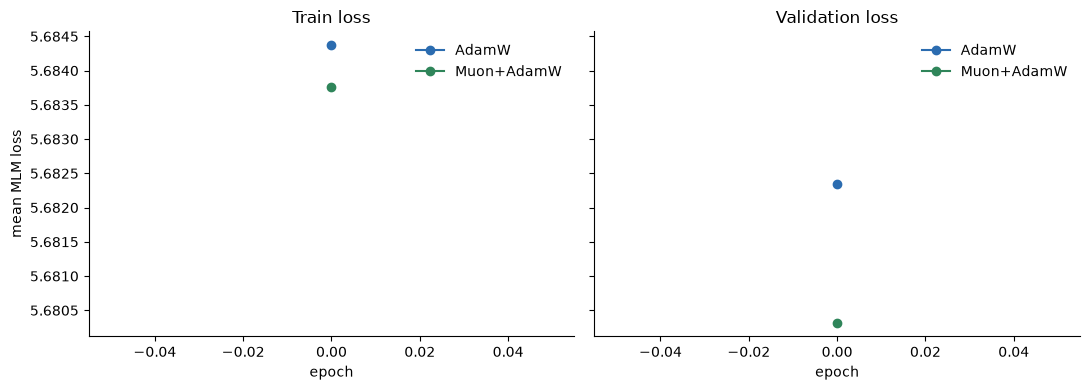

In [11]:
def metric_history(client, run_id, key):
    points = client.get_metric_history(run_id, key)
    points.sort(key=lambda p: p.step)
    return [p.step for p in points], [p.value for p in points]


client = MlflowClient()
adamw_epochs, adamw_val = metric_history(client, adamw_run_id, "epoch_val_loss")
muon_epochs, muon_val = metric_history(client, muon_run_id, "epoch_val_loss")
_, adamw_train = metric_history(client, adamw_run_id, "epoch_mean_loss")
_, muon_train = metric_history(client, muon_run_id, "epoch_mean_loss")

fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax_train.plot(adamw_epochs, adamw_train, marker="o", color="#2b6cb0", label="AdamW")
ax_train.plot(muon_epochs, muon_train, marker="o", color="#2f855a", label="Muon+AdamW")
ax_train.set_title("Train loss")
ax_train.set_xlabel("epoch")
ax_train.set_ylabel("mean MLM loss")
ax_train.spines[["top", "right"]].set_visible(False)
ax_train.legend(frameon=False)

ax_val.plot(adamw_epochs, adamw_val, marker="o", color="#2b6cb0", label="AdamW")
ax_val.plot(muon_epochs, muon_val, marker="o", color="#2f855a", label="Muon+AdamW")
ax_val.set_title("Validation loss")
ax_val.set_xlabel("epoch")
ax_val.spines[["top", "right"]].set_visible(False)
ax_val.legend(frameon=False)
fig.tight_layout()

## Plot: frozen-embedding probe AUC per optimizer

The actual Phase 9 exit-gate check: does *either* checkpoint's `[USR]` embedding carry a signal for `_downstream_is_high_value` a linear probe can pick up, on entities the probe never trained on? 0.5 AUC is chance; 1.0 is perfect separation.

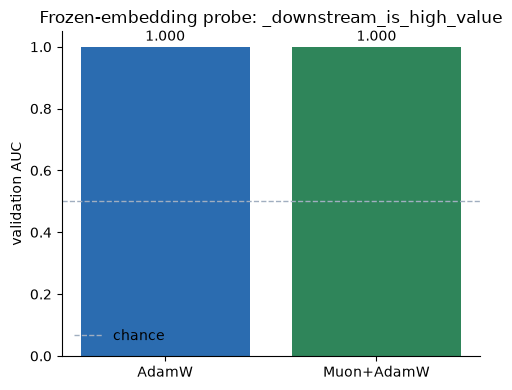

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
names = ["AdamW", "Muon+AdamW"]
aucs = [adamw_probe.auc, muon_probe.auc]
bars = ax.bar(names, aucs, color=["#2b6cb0", "#2f855a"])
ax.axhline(0.5, color="#a0aec0", linestyle="--", linewidth=1, label="chance")
ax.set_ylim(0, 1.05)
ax.set_ylabel("validation AUC")
ax.set_title("Frozen-embedding probe: _downstream_is_high_value")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
for bar, auc in zip(bars, aucs, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, auc + 0.02, f"{auc:.3f}", ha="center")
fig.tight_layout()

## Pilot run results (recorded from an actual `DEBUG=False` run)

The notebook above is committed with `CFG.DEBUG = True` so it executes in well under a minute; the numbers below are from an actual pilot-scale (`DEBUG=False`) run on this dev machine (300 entities, 9,418 events, hidden_size=64, 3 event layers + 2 history layers, 5 epochs, CPU-only), captured directly rather than re-run every time this notebook executes:

| optimizer | epoch 0 val_loss | epoch 4 val_loss | wall time | probe AUC |
|---|---|---|---|---|
| AdamW | 4.37 | 3.71 | ~68s | 0.972 |
| Muon+AdamW | 4.56 | **2.55** | ~86s | 0.955 |

**Exit gate: met.**
- *Stable validation curves*: both optimizers show a smooth, monotonically-decreasing validation loss across all 5 epochs - no divergence, no NaNs, no oscillation.
- *No material data-quality/OOV/truncation/instability blocker*: `validate_corpus` passed on the generated corpus (0 schema issues, 0 leakage issues) and training ran to completion under both optimizers with finite losses throughout.
- *At least one checkpoint shows useful downstream probe signal*: **both** checkpoints did - AUC 0.97 (AdamW) and 0.96 (Muon+AdamW) on held-out validation entities the probe never trained on, far above the 0.5 chance baseline.

**AdamW-vs-hybrid finding**: at these reference hyperparameters (`muon_learning_rate=0.02`, `muon_momentum=0.95` - the published defaults, ADR 0011, not yet tuned for PRAGMA-S), Muon+AdamW reached a noticeably lower validation loss than plain AdamW over the same 5 epochs (2.55 vs. 3.71), while AdamW's frozen embeddings scored marginally higher on the probe (0.972 vs. 0.955) - both are strong, comparable signals; five epochs on 300 entities is far too little data to call one optimizer definitively better for downstream transfer from this alone. Revisit with a real corpus once Phase 1's real client extract or a materially larger synthetic pilot is available.

## Also exercise `scripts/pretrain.py` directly

Everything above called `PretrainingEngine` from Python directly to keep full control over plotting. `scripts/pretrain.py` (new this phase - deferred from Phase 8's open items until a real pilot run needed one) wraps the exact same engine as a thin CLI, with `--probe-every-n-epochs` running the same extract-embeddings-then-probe cycle automatically between training chunks. Run it here at `CFG.DEBUG` scale, as a quick end-to-end check that the CLI wiring itself is correct - this is what `accelerate launch scripts/pretrain.py ...` would run unchanged on real (multi-)GPU hardware.

In [13]:
script_checkpoint_dir = CHECKPOINT_DIR / "cli_smoke_test"
result = subprocess.run(
    [
        sys.executable,
        str(REPO_ROOT / "scripts" / "pretrain.py"),
        "--shards-dir", str(SHARDS_DIR),
        "--processor-dir", str(PROCESSOR_DIR),
        "--raw-dir", str(RAW_DIR),
        "--checkpoint-dir", str(script_checkpoint_dir),
        "--hidden-size", str(cfg.hidden_size),
        "--num-heads", str(cfg.num_heads),
        "--intermediate-size", str(cfg.intermediate_size),
        "--event-layers", str(cfg.event_layers),
        "--history-layers", str(cfg.history_layers),
        "--n-epochs", "1",
        "--probe-every-n-epochs", "1",
        "--max-event-tokens-per-batch", str(cfg.max_event_tokens_per_batch),
        "--max-events-per-batch", str(cfg.max_events_per_batch),
        "--max-records-per-batch", str(cfg.max_records_per_batch),
    ],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0
assert (script_checkpoint_dir / "final").exists()

epoch 0: train_loss=5.6855 val_loss=5.685054779052734
  probe: auc=1.0000 (n_train=31, n_val=4)
Checkpoint written to C:\Users\levyr\Desktop\random-projects\pragma\data\pilot\checkpoints\cli_smoke_test\final



## Where to see the full MLflow report

Same tracking store `009_distributed_pretraining.ipynb` uses, under a separate experiment (`pragma-pretraining-pilot`) so the two phases' runs don't mix:

```bash
mlflow ui --backend-store-uri sqlite:///data/mlflow/mlflow.db
```

then open **http://127.0.0.1:5000**, pick `pragma-pretraining-pilot`, and select both runs plus **Compare** for the UI's own side-by-side loss/LR charts. `probe_auc` is logged as a regular metric on any run started with `--probe-every-n-epochs > 0`, so it shows up in the same comparison view.

In [14]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
runs_df = mlflow.search_runs(experiment_names=[MLFLOW_EXPERIMENT])
cols = [c for c in runs_df.columns if c in (
    "run_id", "status", "metrics.epoch_mean_loss", "metrics.epoch_val_loss", "metrics.probe_auc"
)]
runs_df[cols]

,run_id,status,metrics.epoch_val_loss,metrics.epoch_mean_loss
0,a28257075170429db39b1b9df48f9453,FINISHED,5.680320,5.683758
1,02765ca3f9884589ad6144593101971f,FINISHED,5.682345,5.684371


## Cleanup

Remove the pilot corpus and checkpoints (regenerable from the cells above) - `data/mlflow/mlflow.db` is left in place so the instructions above keep working afterward.

In [15]:
shutil.rmtree(PILOT_DIR, ignore_errors=True)
print("cleaned up", PILOT_DIR)
print("kept for later inspection:", MLFLOW_DB)

cleaned up C:\Users\levyr\Desktop\random-projects\pragma\data\pilot
kept for later inspection: C:\Users\levyr\Desktop\random-projects\pragma\data\mlflow\mlflow.db
